

Descripción del problema

El banco portugués está teniendo una disminución en sus ingresos, por lo que quieren poder identificar a los clientes existentes que tienen una mayor probabilidad de contratar un depósito a largo plazo. Esto permitirá que el banco centre sus esfuerzos de marketing en esos clientes y evitará perder dinero y tiempo en clientes que probablemente no se suscribirán.

El objetivo de este proyecto es predecir si un cliente de un banco portugués
contratará un **depósito a largo plazo** (`y = 'yes'` / `'no'`), a partir de
datos de campañas de marketing telefónicas.

Seguiremos los pasos clásicos del EDA:
1. Carga y primera exploración
2. Limpieza de datos
3. Análisis univariante
4. Análisis multivariante
5. Ingeniería de características
6. Selección de características
7. Modelo de regresión logística
8. Optimización del modelo


## 00 Librerias

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_selection import f_classif, SelectKBest
from sklearn.model_selection import RandomizedSearchCV
import warnings
warnings.filterwarnings('ignore')
# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


## Paso 1: Carga del conjunto de datos

In [4]:
# Cargamos el dataset
url = "https://storage.googleapis.com/breathecode/project-files/bank-marketing-campaign-data.csv"

df = pd.read_csv(url, sep=';')

# Guardamos la variable objetivo 
TARGET_COL = 'y'

df.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
print(f"Filas: {df.shape[0]}  |  Columnas: {df.shape[1]}")


Filas: 41188  |  Columnas: 21


## Paso 2: Exploración y limpieza de datos

### 2.1 Tipos de datos y valores nulos


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [7]:
# Porcentaje de valores nulos por columna
nulos = df.isnull().sum()
pct   = (nulos / len(df) * 100).round(2)
pd.DataFrame({"Nulos": nulos, "Porcentaje %": pct})[nulos > 0]


,Nulos,Porcentaje %


**Nota:** El dataset de marketing bancario no suele tener NaN explícitos,
pero sí valores categóricos como: unknown, que trataremos como datos faltantes.


In [8]:
# Revisamos cuántos 'unknown' hay por columna categórica (excluimos la variable objetivo)
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols_sin_y = [c for c in cat_cols if c != TARGET_COL]

unknowns = {col: (df[col] == 'unknown').sum() for col in cat_cols_sin_y}
unknowns_df = pd.DataFrame.from_dict(unknowns, orient='index', columns=['unknown_count'])
unknowns_df['pct'] = (unknowns_df['unknown_count'] / len(df) * 100).round(2)
unknowns_df[unknowns_df['unknown_count'] > 0]


,unknown_count,pct
job,330,0.80
marital,80,0.19
education,1731,4.20
default,8597,20.87
housing,990,2.40
loan,990,2.40


In [9]:
# Reemplazamos 'unknown' por NaN SOLO en las columnas predictoras (nunca en 'y')
for col in cat_cols_sin_y:
    df[col] = df[col].replace('unknown', np.nan)

# Rellenamos con la moda (valor más frecuente) en cada columna
for col in cat_cols_sin_y:
    if df[col].isnull().any():
        moda = df[col].mode()[0]
        df[col].fillna(moda, inplace=True)
        print(f"  '{col}' -> rellenado con moda = '{moda}'")

print("\n✅ Valores 'unknown' tratados correctamente.")
print(f"Variable objetivo '{TARGET_COL}' intacta: {df[TARGET_COL].unique()}")


  'job' -> rellenado con moda = 'admin.'
  'marital' -> rellenado con moda = 'married'
  'education' -> rellenado con moda = 'university.degree'
  'default' -> rellenado con moda = 'no'
  'housing' -> rellenado con moda = 'yes'
  'loan' -> rellenado con moda = 'no'

✅ Valores 'unknown' tratados correctamente.
Variable objetivo 'y' intacta: ['no' 'yes']


### 2.2 Estadísticas descriptivas

In [10]:
# Variables numéricas
df.describe().round(2)


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00,41188.00
mean,40.02,258.29,2.57,962.48,0.17,0.08,93.58,-40.50,3.62,5167.04
std,10.42,259.28,2.77,186.91,0.49,1.57,0.58,4.63,1.73,72.25
min,17.00,0.00,1.00,0.00,0.00,-3.40,92.20,-50.80,0.63,4963.60
25%,32.00,102.00,1.00,999.00,0.00,-1.80,93.08,-42.70,1.34,5099.10
50%,38.00,180.00,2.00,999.00,0.00,1.10,93.75,-41.80,4.86,5191.00
75%,47.00,319.00,3.00,999.00,0.00,1.40,93.99,-36.40,4.96,5228.10
max,98.00,4918.00,56.00,999.00,7.00,1.40,94.77,-26.90,5.04,5228.10


In [11]:
# Variables categóricas
df.describe(include='object')


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,11,3,7,2,2,2,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10752,25008,13899,41185,22566,34940,26144,13769,8623,35563,36548


### 2.3 Duplicados

In [12]:
dupl = df.duplicated().sum()
print(f"Filas duplicadas: {dupl}")




Filas duplicadas: 14


In [13]:
#eliminamos duplicados 
df.drop_duplicates(inplace=True)
print(f"Forma del dataset tras eliminar duplicados: {df.shape}")


Forma del dataset tras eliminar duplicados: (41174, 21)


## Paso 3: Análisis univariante

### 3.1 Variable objetivo y


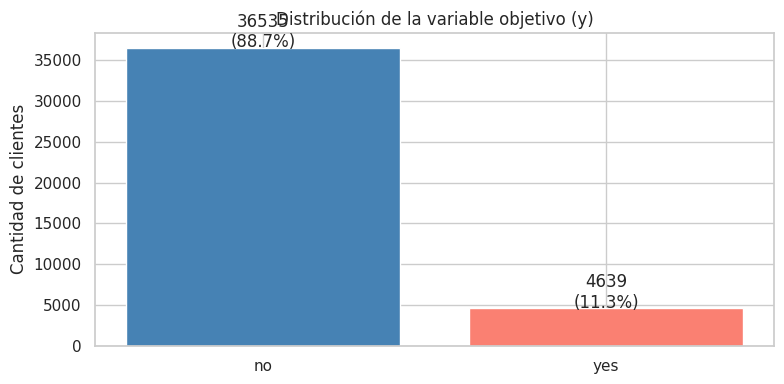

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))

counts = df[TARGET_COL].value_counts()
ax.bar(counts.index, counts.values, color=['steelblue', 'salmon'])
ax.set_title('Distribución de la variable objetivo (y)')
ax.set_ylabel('Cantidad de clientes')
for i, v in enumerate(counts.values):
    ax.text(i, v + 50, f"{v}\n({v/len(df)*100:.1f}%)", ha='center')

plt.tight_layout()
plt.show()


> **Observación:** El dataset está **desbalanceado** — la mayoría de clientes
NO contratan el depósito (`no`). Esto es importante para el modelo.


### 3.2 Variables numéricas

Variables numéricas: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


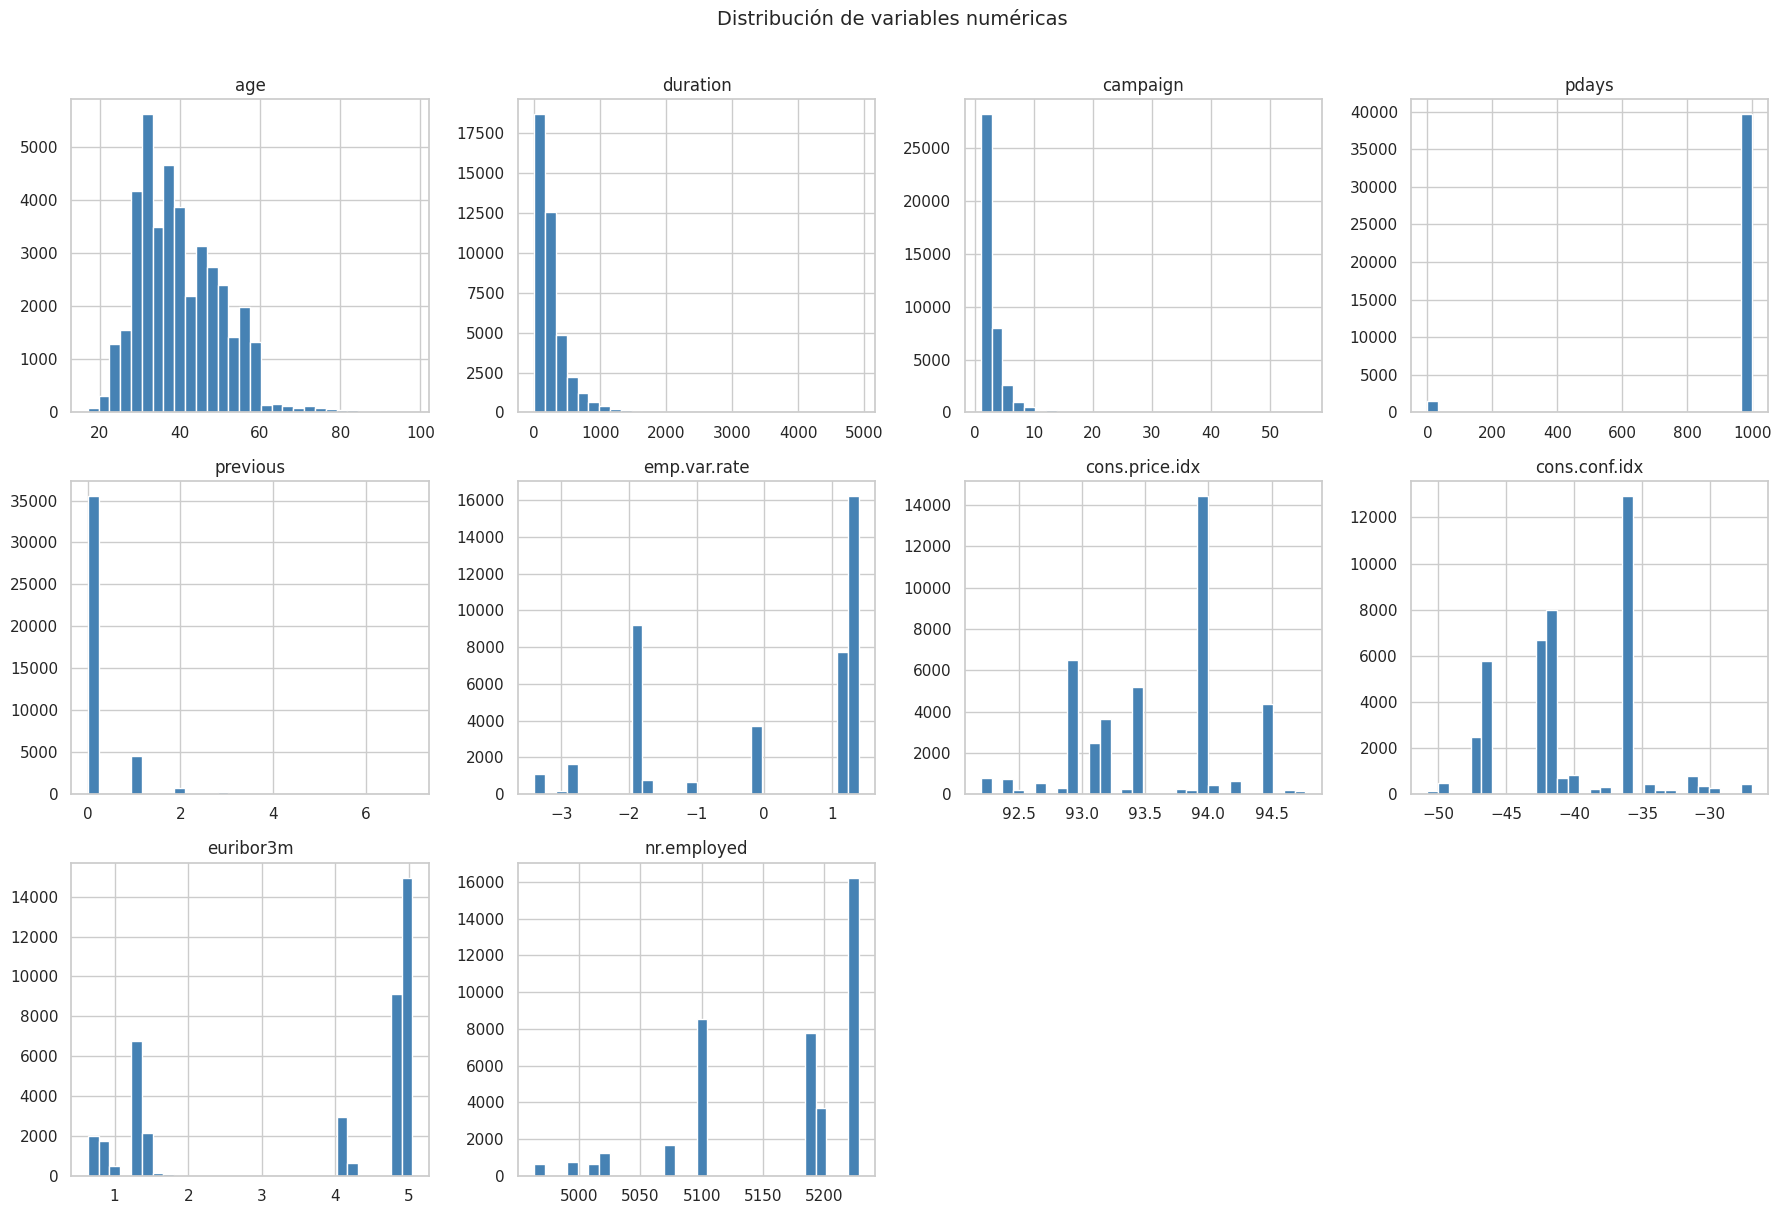

In [15]:
num_cols = df.select_dtypes(include='number').columns.tolist()
print("Variables numéricas:", num_cols)

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('')

# Ocultamos los ejes sobrantes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables numéricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


### 3.3 Detección de outliers (boxplots)

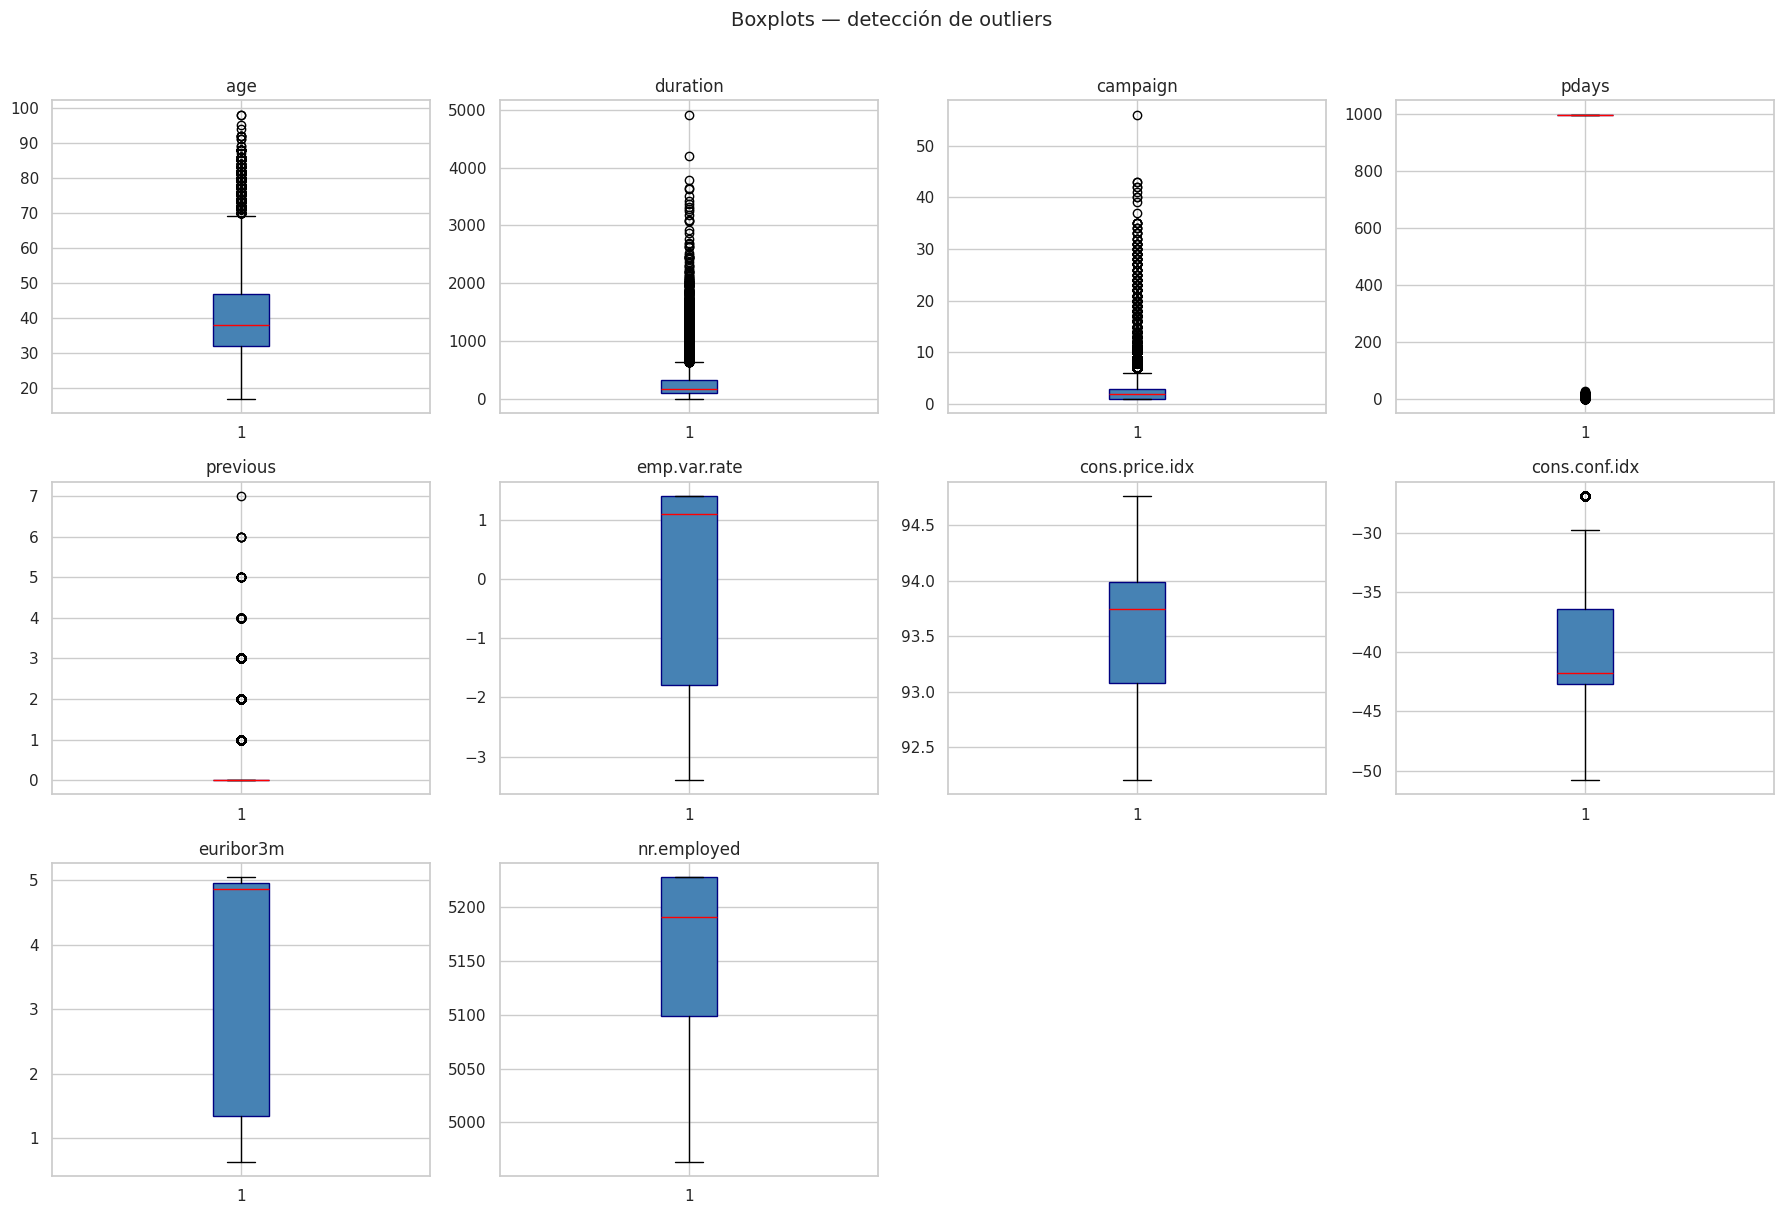

In [16]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', color='navy'),
                    medianprops=dict(color='red'))
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots — detección de outliers', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


In [17]:
# Cuantificamos outliers con método IQR
print("Outliers detectados por columna (método IQR):\n")
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"  {col}: {n_out} outliers  [{lower:.2f}, {upper:.2f}]")


Outliers detectados por columna (método IQR):

  age: 468 outliers  [9.50, 69.50]
  duration: 2963 outliers  [-223.50, 644.50]
  campaign: 2406 outliers  [-2.00, 6.00]
  pdays: 1515 outliers  [999.00, 999.00]
  previous: 5625 outliers  [0.00, 0.00]
  emp.var.rate: 0 outliers  [-6.60, 6.20]
  cons.price.idx: 0 outliers  [91.70, 95.37]
  cons.conf.idx: 446 outliers  [-52.15, -26.95]
  euribor3m: 0 outliers  [-4.08, 10.39]
  nr.employed: 0 outliers  [4905.60, 5421.60]


### 3.4 Variables categóricas

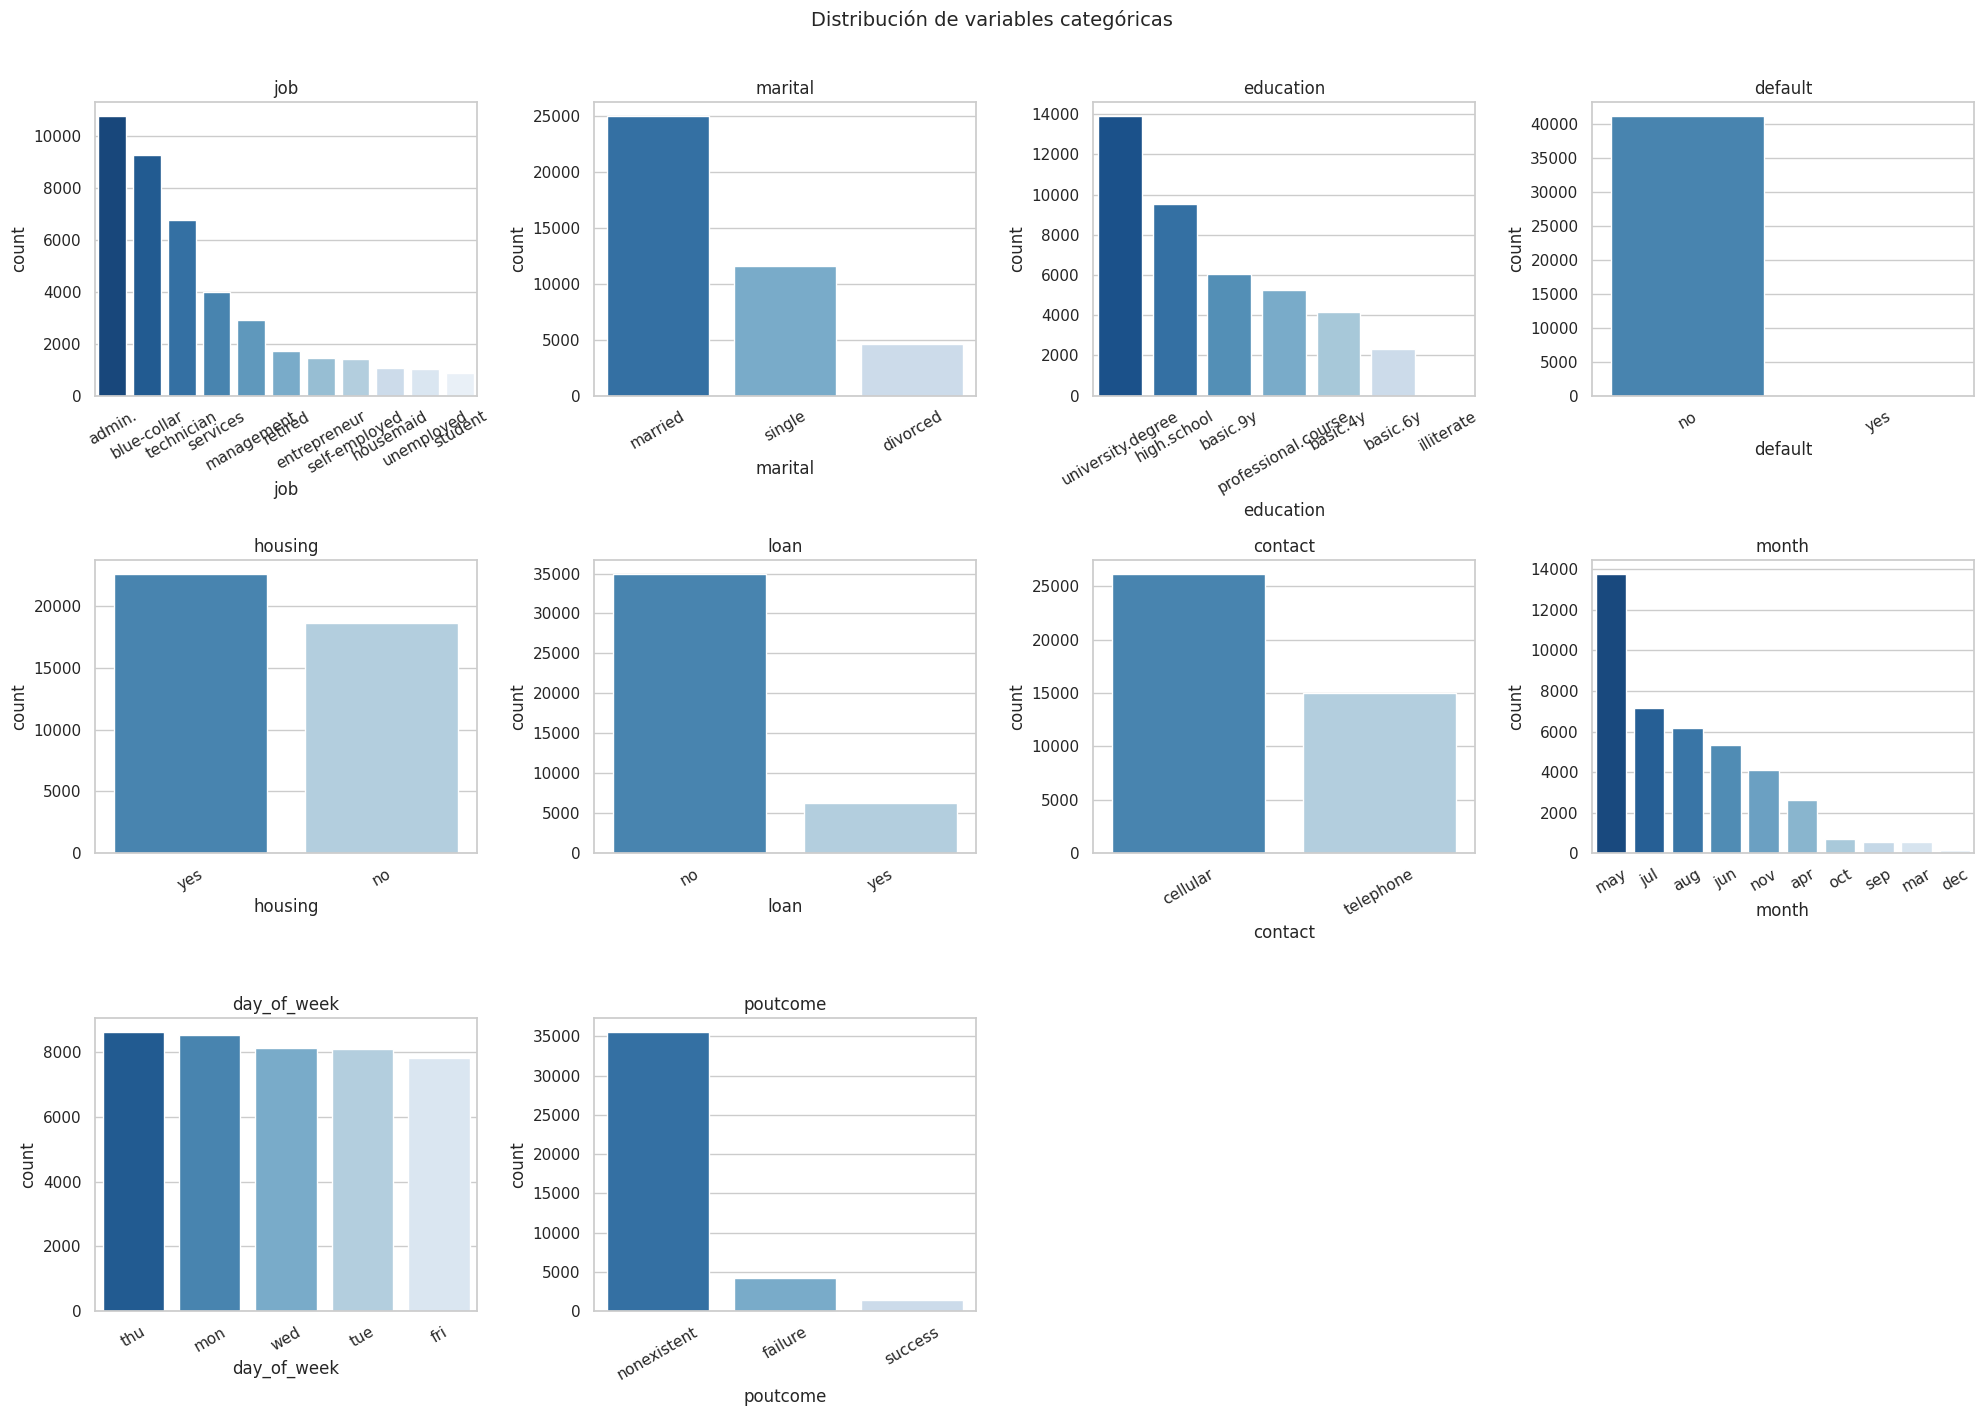

In [18]:
# cat_cols_sin_y ya fue definida en el Paso 2
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols_sin_y):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=axes[i],
                  palette='Blues_r')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables categóricas', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## Paso 4: Análisis multivariante

### 4.1 Correlación entre variables numéricas


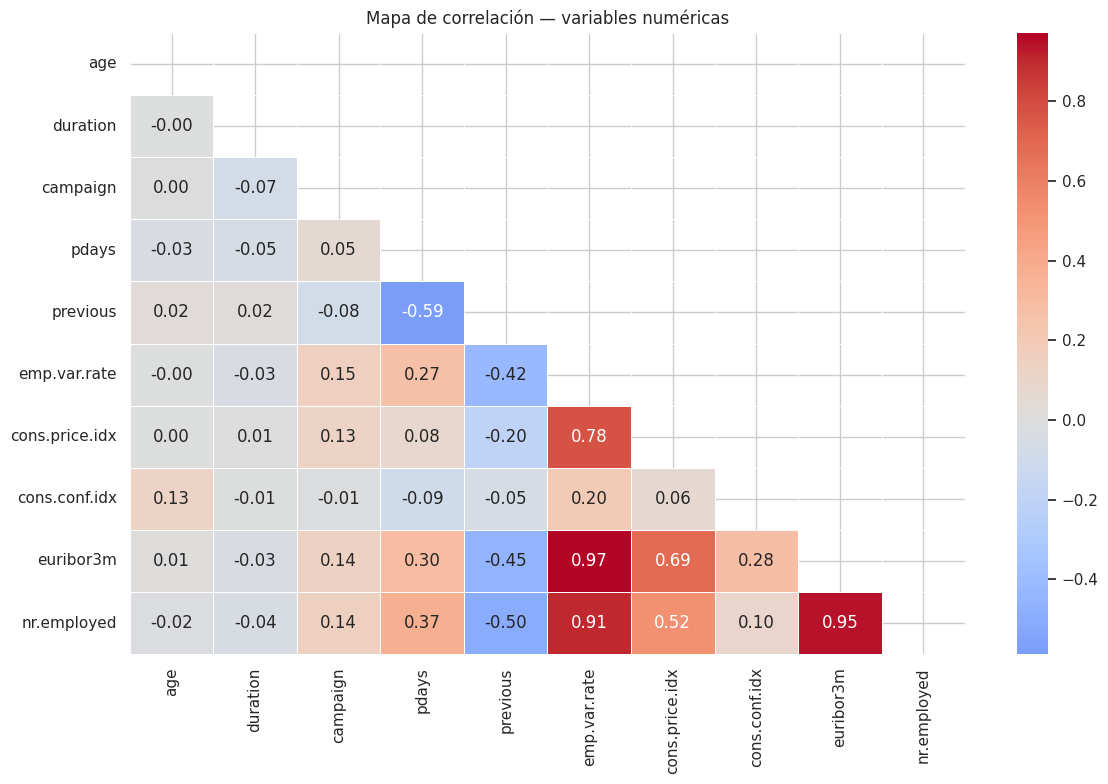

In [19]:
corr = df[num_cols].corr()

plt.figure(figsize=(12, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Mapa de correlación — variables numéricas')
plt.tight_layout()
plt.show()


 Variables macroeconómicas como euribor3m, emp.var.rate
y nr.employed, están muy correlacionadas entre sí. 

### 4.2 Variables categóricas vs variable objetivo (`y`)

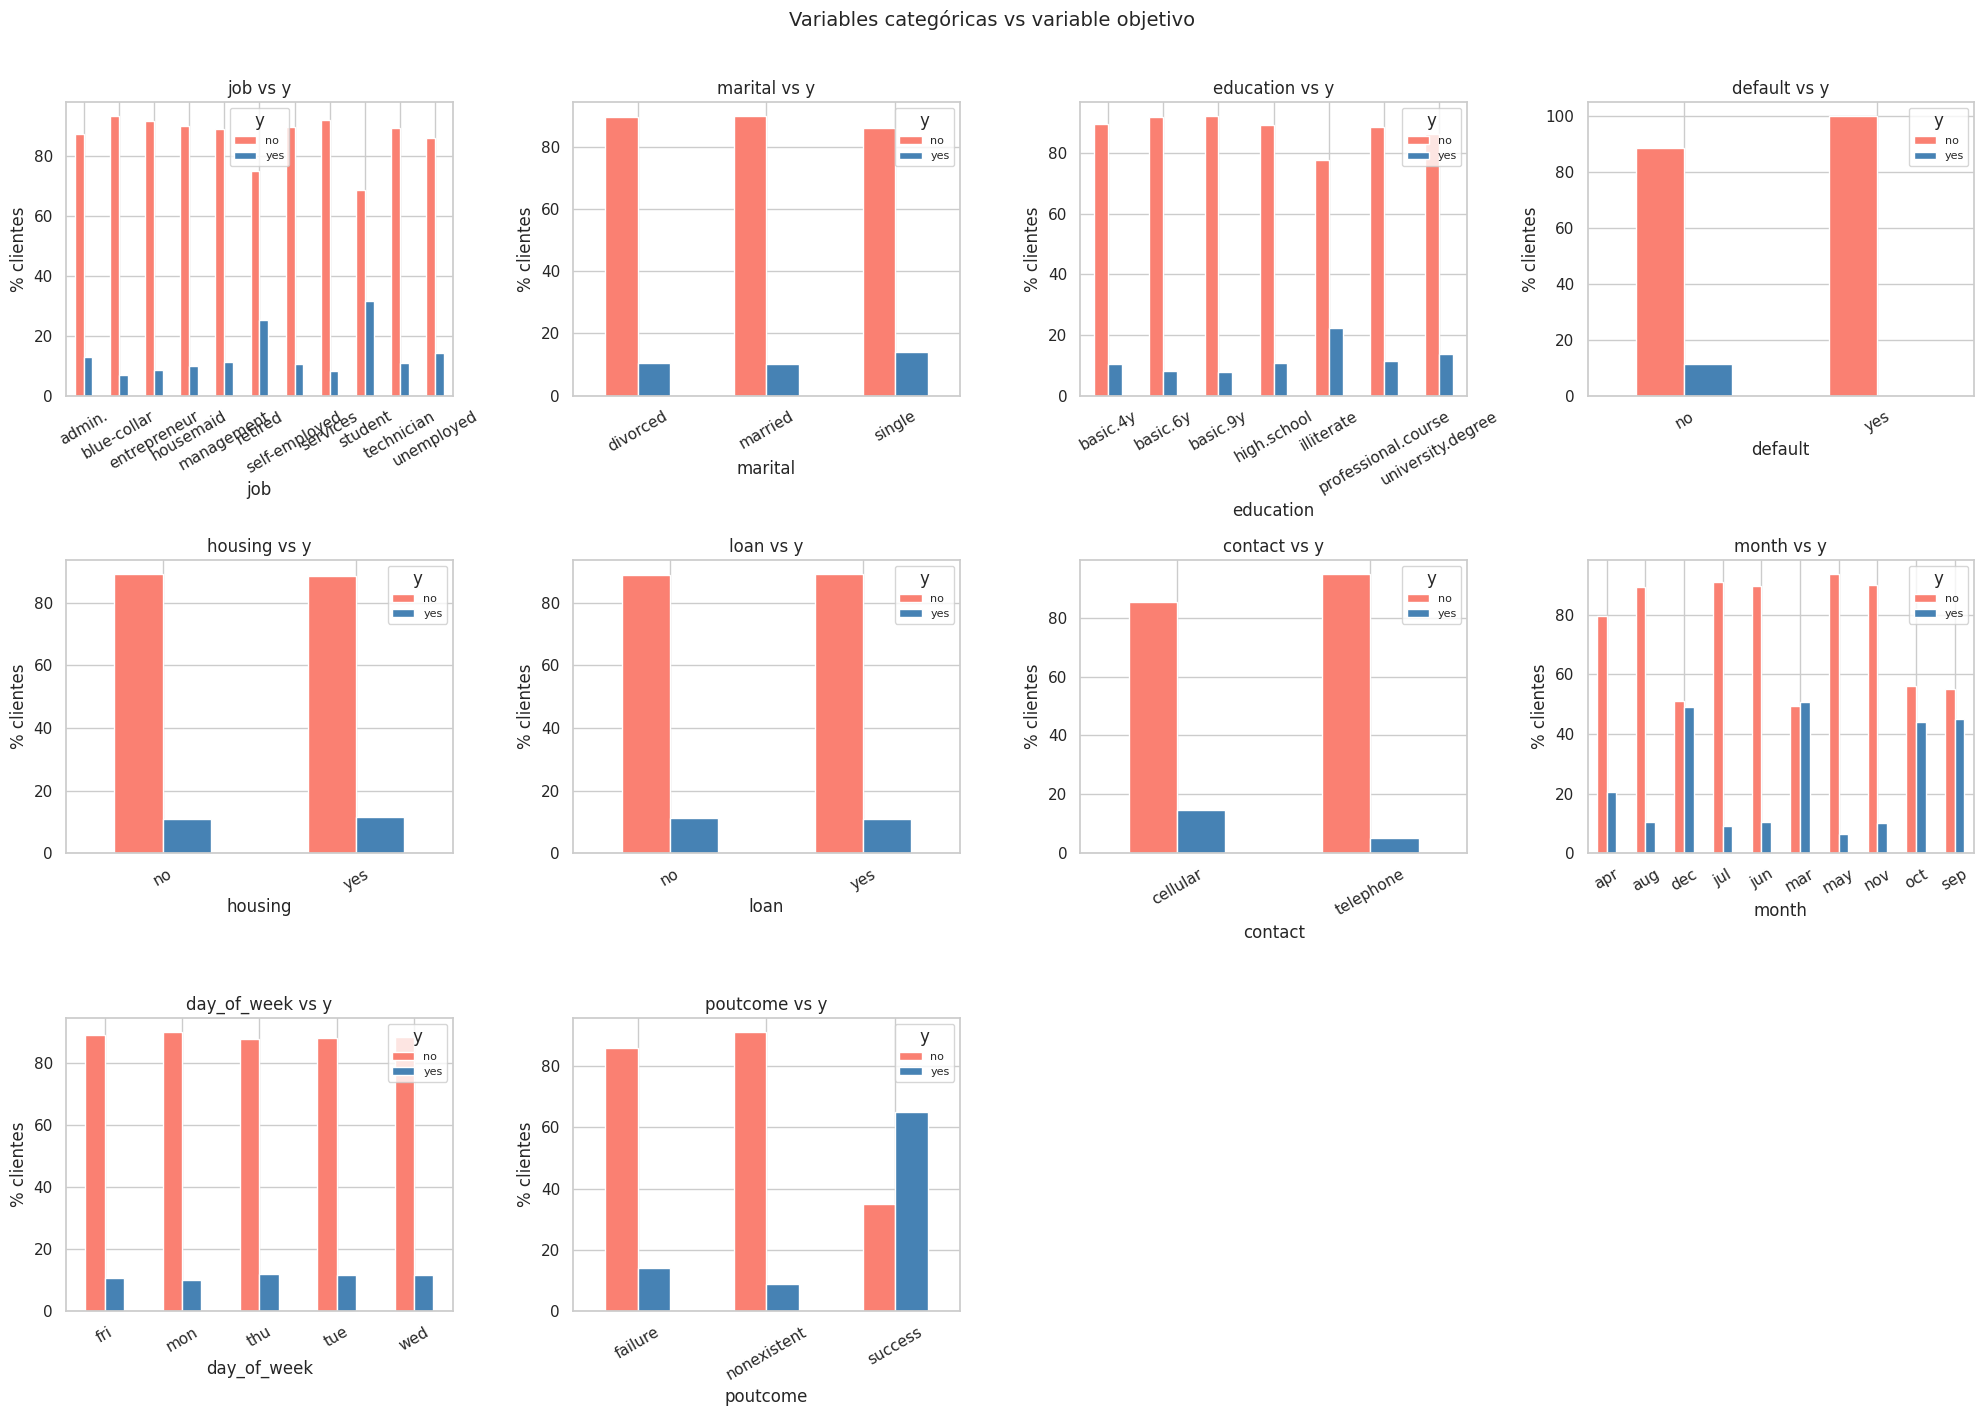

In [20]:
fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols_sin_y):
    pct = (df.groupby(col)[TARGET_COL]
             .value_counts(normalize=True)
             .unstack()
             .fillna(0) * 100)
    pct.plot(kind='bar', ax=axes[i], color=['salmon', 'steelblue'],
             edgecolor='white')
    axes[i].set_title(f'{col} vs y')
    axes[i].set_ylabel('% clientes')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='y', fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Variables categóricas vs variable objetivo', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


### 4.3 Variables numéricas vs variable objetivo

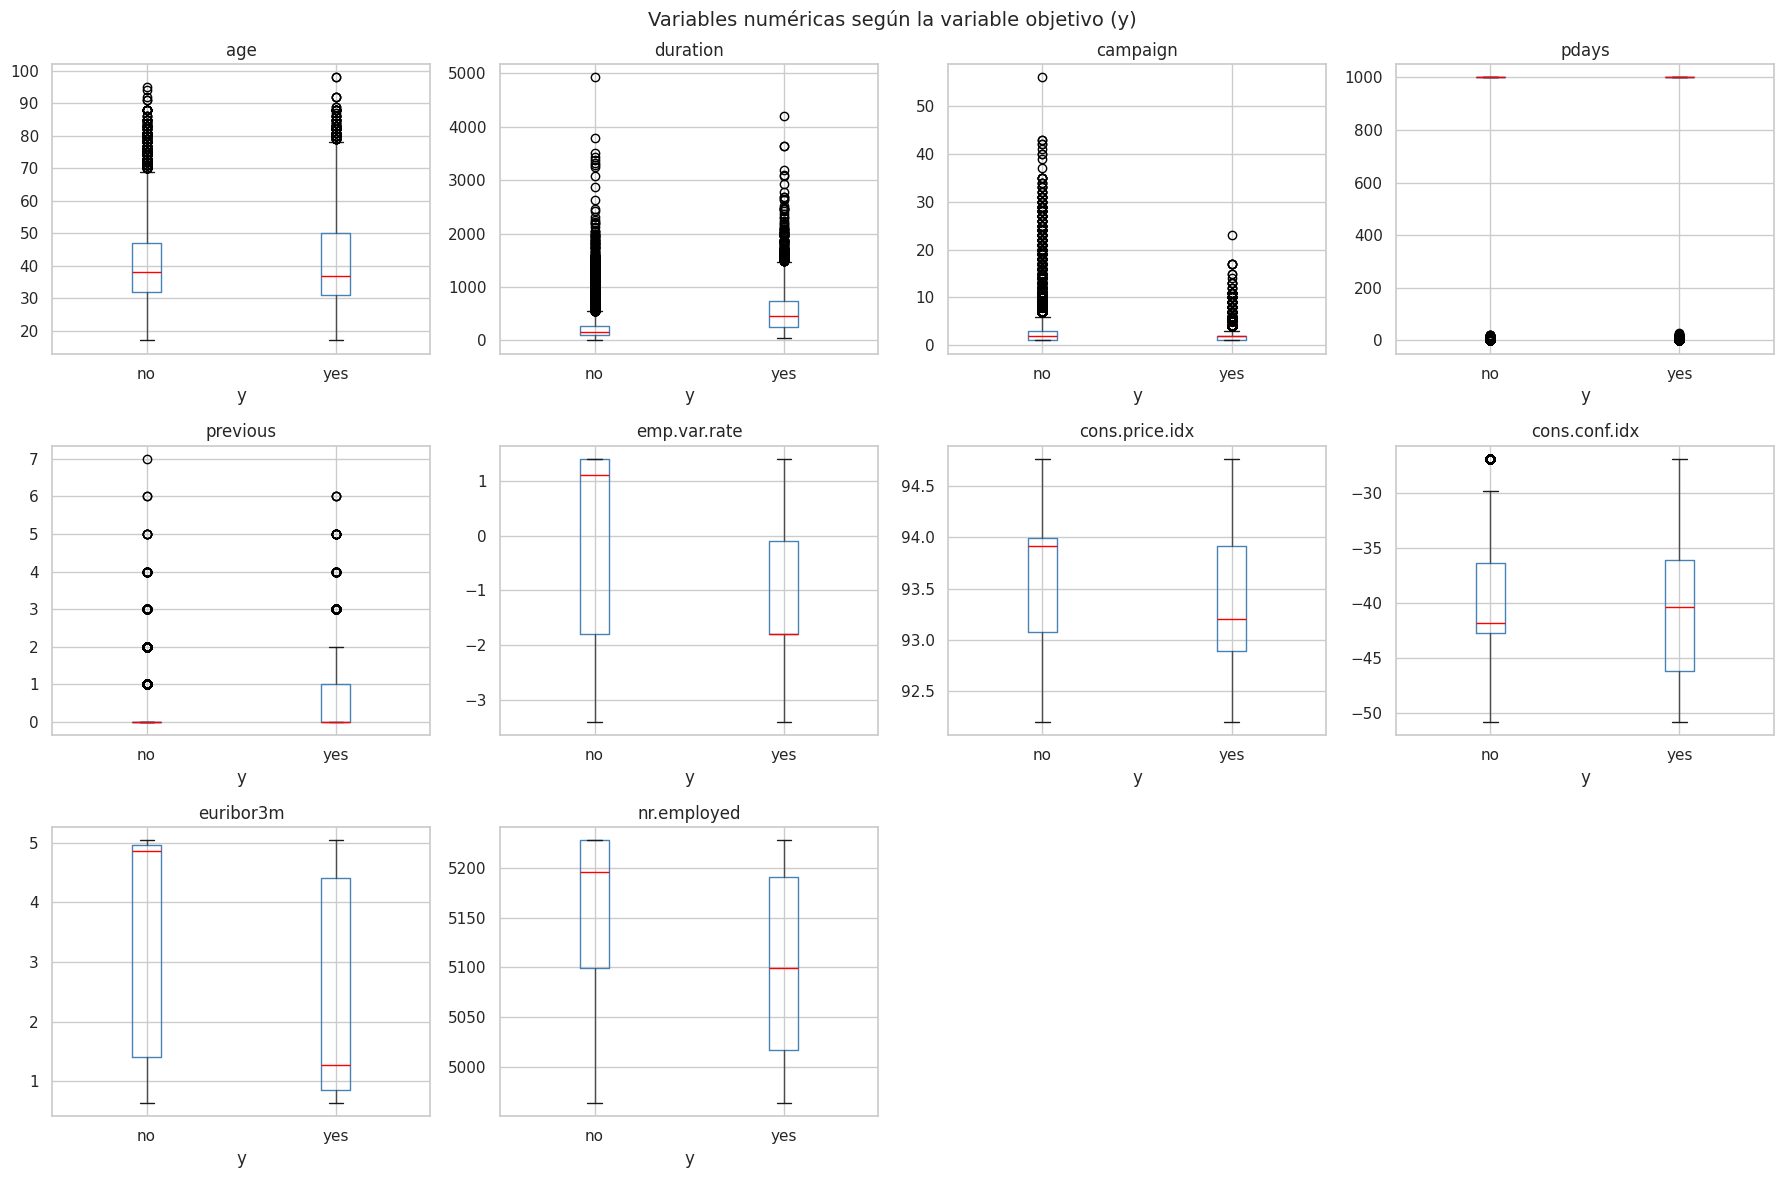

In [21]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df.boxplot(column=col, by=TARGET_COL, ax=axes[i],
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red'))
    axes[i].set_title(col)
    axes[i].set_xlabel('y')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Variables numéricas según la variable objetivo (y)', fontsize=14)
plt.tight_layout()
plt.show()


## Paso 5: Ingeniería de características

### 5.1 Codificación de variables categóricas (Label Encoding)


In [22]:
df_model = df.copy()

# Codificamos la variable objetivo
df_model['y_n'] = (df_model[TARGET_COL] == 'yes').astype(int)
print("Distribución de y_n:")
print(df_model['y_n'].value_counts())


Distribución de y_n:
y_n
0    36535
1     4639
Name: count, dtype: int64


In [23]:
# Label Encoding para el resto de variables categóricas
le = LabelEncoder()
for col in cat_cols_sin_y:
    df_model[col + '_n'] = le.fit_transform(df_model[col].astype(str))

# Eliminamos columnas originales de texto
cols_a_eliminar = cat_cols_sin_y + [TARGET_COL]
df_model.drop(columns=cols_a_eliminar, inplace=True)

print("Columnas finales del dataset:")
print(df_model.columns.tolist())


Columnas finales del dataset:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y_n', 'job_n', 'marital_n', 'education_n', 'default_n', 'housing_n', 'loan_n', 'contact_n', 'month_n', 'day_of_week_n', 'poutcome_n']


### 5.2 Eliminación de variables altamente correlacionadas

In [24]:
# Eliminamos columnas macroeconómicas muy correlacionadas para reducir multicolinealidad
# Nos quedamos con euribor3m como representante del entorno económico
cols_drop_corr = ['nr.employed', 'emp.var.rate']
df_model.drop(columns=cols_drop_corr, inplace=True)
print(f"Dataset después de eliminar columnas correlacionadas: {df_model.shape}")


Dataset después de eliminar columnas correlacionadas: (41174, 19)


### 5.3 Tratamiento de outliers

In [25]:
# Creamos dos versiones: con y sin outliers (para comparar en el modelo)
df_SIN_outliers = df_model.copy()

cols_num_model = [c for c in df_model.select_dtypes(include='number').columns
                  if c != 'y_n']

for col in cols_num_model:
    Q1 = df_SIN_outliers[col].quantile(0.25)
    Q3 = df_SIN_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_SIN_outliers[col] = df_SIN_outliers[col].clip(lower, upper)

print("Outliers tratados con recorte (clipping) en df_SIN_outliers")
print(f"Forma: {df_SIN_outliers.shape}")


Outliers tratados con recorte (clipping) en df_SIN_outliers
Forma: (41174, 19)


## Paso 6: Selección de características y split train/test

### 6.1 División del dataset


In [26]:
X = df_SIN_outliers.drop(columns=['y_n'])
y_target = df_SIN_outliers['y_n']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_target, test_size=0.2, random_state=42, stratify=y_target
)

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train — clase 1 (yes): {y_train.mean()*100:.1f}%")
print(f"y_test  — clase 1 (yes): {y_test.mean()*100:.1f}%")


X_train: (32939, 18)  |  X_test: (8235, 18)
y_train — clase 1 (yes): 11.3%
y_test  — clase 1 (yes): 11.3%


### 6.2 Selección de características con SelectKBest (ANOVA F-test)

In [27]:
selection_model = SelectKBest(f_classif, k=10)
selection_model.fit(X_train, y_train)

ix = selection_model.get_support()
X_train_sel = pd.DataFrame(
    selection_model.transform(X_train),
    columns=X_train.columns.values[ix]
)
X_test_sel = pd.DataFrame(
    selection_model.transform(X_test),
    columns=X_test.columns.values[ix]
)

# Puntuaciones de cada característica
scores = pd.DataFrame({
    'feature': X_train.columns,
    'score': selection_model.scores_,
    'selected': ix
}).sort_values('score', ascending=False)

print("Top características seleccionadas:\n")
print(scores.to_string(index=False))


Top características seleccionadas:

       feature       score  selected
      duration 6376.224919      True
     euribor3m 3339.456960      True
     contact_n  716.390863      True
cons.price.idx  584.011443      True
      campaign  159.908276      True
   education_n   99.976552      True
 cons.conf.idx   95.899644      True
     marital_n   72.769265      True
           age   19.098555      True
         job_n   18.787421      True
 day_of_week_n    4.088106     False
     housing_n    3.320813     False
       month_n    2.050649     False
         pdays         NaN     False
      previous         NaN     False
     default_n         NaN     False
        loan_n         NaN     False
    poutcome_n         NaN     False


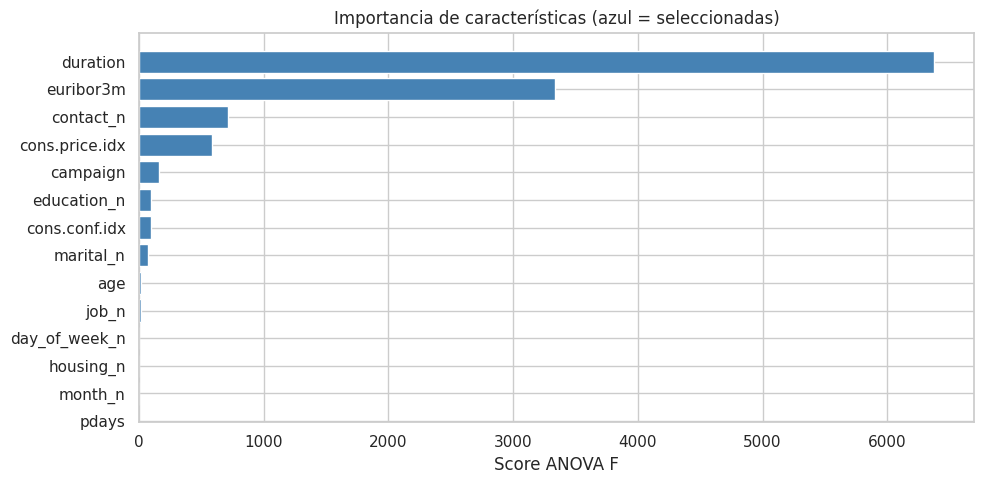


Características seleccionadas: ['age', 'duration', 'campaign', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'job_n', 'marital_n', 'education_n', 'contact_n']


In [28]:
# Visualizamos la importancia
top = scores.head(15)
plt.figure(figsize=(10, 5))
colors = ['steelblue' if s else 'lightgray' for s in top['selected']]
plt.barh(top['feature'], top['score'], color=colors)
plt.xlabel('Score ANOVA F')
plt.title('Importancia de características (azul = seleccionadas)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nCaracterísticas seleccionadas:", X_train_sel.columns.tolist())


## Paso 7: Modelo de regresión logística

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Modelo base con parámetros por defecto
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_sel, y_train)

y_pred = log_reg.predict(X_test_sel)

print("=" * 50)
print("RESULTADOS — Modelo Base (Regresión Logística)")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print()
print(classification_report(y_test, y_pred, target_names=['No (0)', 'Sí (1)']))


RESULTADOS — Modelo Base (Regresión Logística)
Accuracy: 90.41%

              precision    recall  f1-score   support

      No (0)       0.92      0.97      0.95      7307
      Sí (1)       0.63      0.35      0.45       928

    accuracy                           0.90      8235
   macro avg       0.78      0.66      0.70      8235
weighted avg       0.89      0.90      0.89      8235



## Paso 8: Optimización del modelo

### 8.1 Estrategia: ajuste del parámetro class_weight='balanced

Como el dataset está desbalanceado (~89% 'no' vs ~11% 'yes'), aplicamos
class_weight='balanced para que el modelo penalice más los errores en la
clase minoritaria.


In [31]:
# El modelo base (sin parámetros)
model = LogisticRegression(max_iter=100, random_state=42)

# Definimos los parámetros que queremos ajustar
hyperparams = {
    "C": np.logspace(-4, 4, 20),
    "penalty": ["l1", "l2", "elasticnet", None],
    "solver": ["newton-cg", "lbfgs", "liblinear", "sag", "saga"]
}

# Inicializamos la búsqueda aleatoria
random_search = RandomizedSearchCV(
    model,
    hyperparams,
    n_iter=100,
    scoring="recall",   # usamos recall porque el dataset está desbalanceado
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_sel, y_train)
print(f"Mejores hiperparámetros: {random_search.best_params_}")

Mejores hiperparámetros: {'solver': 'newton-cg', 'penalty': 'l2', 'C': np.float64(4.281332398719396)}


In [32]:
# Evaluamos el modelo optimizado
mejor_modelo = random_search.best_estimator_
y_pred_random = mejor_modelo.predict(X_test_sel)

print("=" * 55)
print("RESULTADOS — Modelo Optimizado con RandomizedSearchCV")
print("=" * 55)
print(f"Accuracy: {accuracy_score(y_test, y_pred_random)*100:.2f}%")
print()
print(classification_report(y_test, y_pred_random, target_names=['No (0)', 'Si (1)']))

RESULTADOS — Modelo Optimizado con RandomizedSearchCV
Accuracy: 90.24%

              precision    recall  f1-score   support

      No (0)       0.92      0.97      0.95      7307
      Si (1)       0.62      0.34      0.44       928

    accuracy                           0.90      8235
   macro avg       0.77      0.66      0.69      8235
weighted avg       0.89      0.90      0.89      8235



El modelo de regresión logística base logra una accuracy del 90.41%, lo que a primera vista parece un buen resultado. Sin embargo, este número es engañoso debido al fuerte desbalance del dataset (88.7% no vs 11.3% yes).

La optimización con RandomizedSearchCV no logró una mejora significativa, obteniendo resultados prácticamente idénticos (90.24% accuracy, recall Sí = 0.34). Esto indica que el verdadero problema no es el ajuste de hiperparámetros, sino el desbalance de clases.